# Probabilistic dirichlet  search algorithm

In [1]:
import os
import random
import magnum as mn
import numpy as np
import cv2
import copy
import torch
import json
import pickle
from PIL import Image
from ultralytics import YOLO 
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch
from mylib import probtools
import io
import contextlib
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut
from habitat_sim.utils.common import quat_from_angle_axis, quat_to_angle_axis
from habitat_sim.utils.common import d3_40_colors_rgb

# Load YOLO model
yolo_model = YOLO("yolov8n.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


100%|██████████| 6.25M/6.25M [00:00<00:00, 10.5MB/s]


In [2]:
# Robotic agent properties
AGENT_RADIUS = 0.15 # 15 cm
AGENT_HEIGHT = 1.0 # 100 cm

# Sensor observations scale
OBS_SCALE = 9/16 # WIDTH/HEIGHT

# Maps sizes
CELL_SIDE = 2*AGENT_RADIUS # 30 cm
MAP_RESOLUTION = 0.01 # 1 cm

# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[2]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera_intrinsics.json', 'r') as f:
    cam_intrcs = json.load(f)

# Load bins per class
with open('simulation-data/bins_per_obj_class.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor_objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

# Load Dirichlet priors
with open('simulation-data/dirichlet_priors.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[16:36:22:351004]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train3_4.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[16:36:22:533336]:[Warning]:[Sim

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_map = myutils.retain_largest_white_chunk(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
occ_grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
occ_grid_map = myutils.map_to_rgb(occ_grid_map)
occ_grid_map = myutils.retain_largest_white_chunk(occ_grid_map)
occ_grid_resolution = occ_grid_map.shape[:2]

# Occupiable positions
grid_occ_positions = []
real_wrld_positions = []
map_occ_positions = []
for x_g in range(occ_grid_resolution[0]):
    for y_g in range(occ_grid_resolution[1]):
        if occ_grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, occ_grid_resolution, pathfinder=sim.pathfinder)
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            if sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) and topdown_map[map_x, map_y, 0] == 255: # White pixel
                real_wrld_positions.append([real_wrld_x, 0.0, real_wrld_z])
                map_occ_positions.append([map_x, map_y])
                grid_occ_positions.append([x_g, y_g]) # Add grid position
            else:
                occ_grid_map[x_g, y_g, :] = [128, 128, 128] # Grey pixel

# Count the number of occupiable positions
num_free_cells = len(grid_occ_positions)

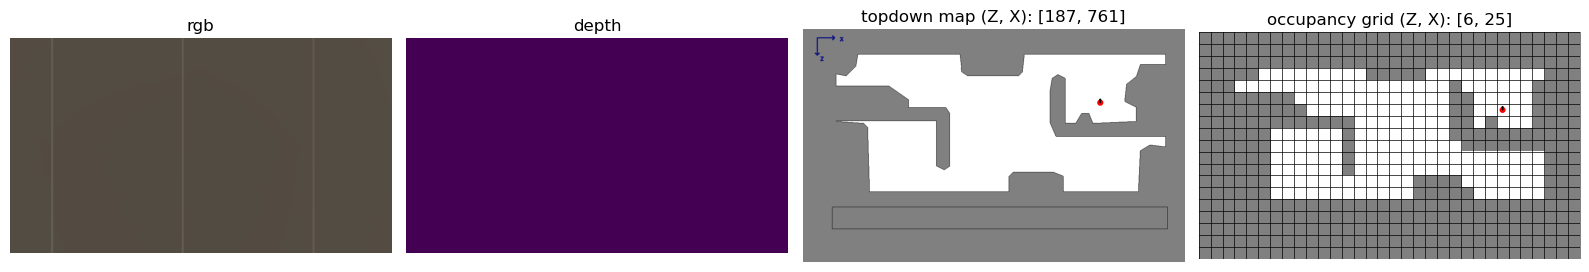

In [4]:
# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_occ_positions)
idx = grid_occ_positions.index(grid_position)
wrld_position = real_wrld_positions[idx]
map_position = map_occ_positions[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = wrld_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
occ_grid_radius = (AGENT_RADIUS / x_dim * occ_grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius_tpl = (topdown_radius, occ_grid_radius)
agent_positions_tpl = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

In [5]:
# Define possible actions
actions = {
    "move_forward",
    "move_backward",
    "move_left",
    "move_right",
    "turn_around",
    "turn_left",
    "turn_right",
}

# Standard thresholds
MAX_ITER = 500
CONFIDENCE_THRESHOLD = 0.75

# Simulation parameters
MAX_NUM_CLUSTERS = num_free_cells
num_clusters = 8
PRIOR_VALUE = 0.5   
NUM_CLASSES = 27 #(excluding background for now)

# Visualization 
DISPLAY_STEP = 5

# Metrics
OBJECT_FOUND = False
num_actions = 0
travelled_distance = 0.0
closeness = float("inf")

# Belief map setup
belief_map = [[np.ones(NUM_CLASSES) * PRIOR_VALUE for _ in range(occ_grid_map.shape[1])] for _ in range(occ_grid_map.shape[0])]

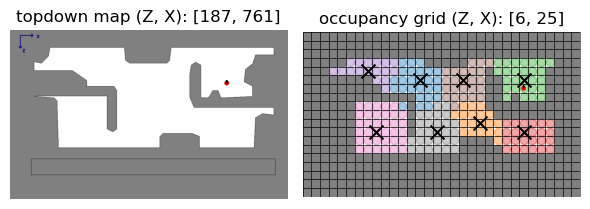

In [6]:
# Cluster grid map, compute cluster centers (observation points) and select the first cluster
obs_points_map = simtools.cluster_mapping(grid_occ_positions, num_clusters)
grid_obs_points = simtools.get_cluster_centers(obs_points_map, num_clusters)
wrld_obs_points = [real_wrld_positions[grid_occ_positions.index(cluster)] for cluster in grid_obs_points]
simtools.display_topdown_maps_with_clusters(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw, obs_points_map, num_clusters, grid_obs_points)

-------------------------------
Number of clusters: 8


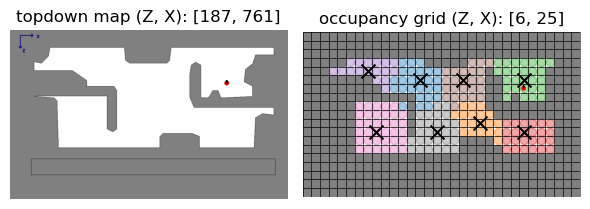

-------------------------------
NEXT CLUSTER: [5, 25]
PATH: [[5, 25]]
Action:  move_forward


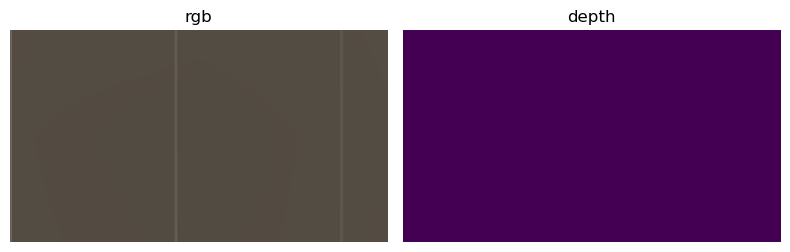

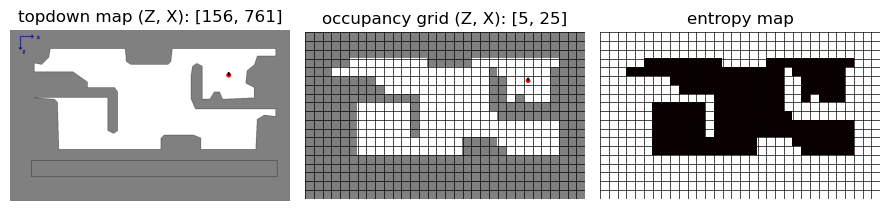

Taking observations at cluster center: [5, 25]
Action:  move_forward


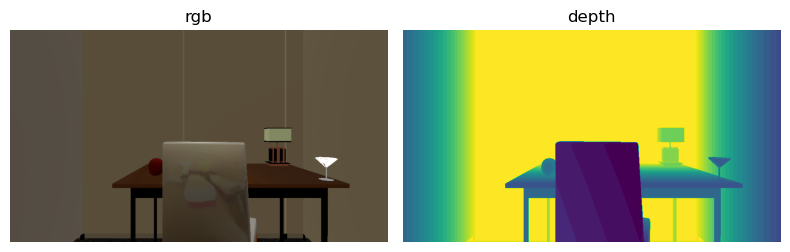

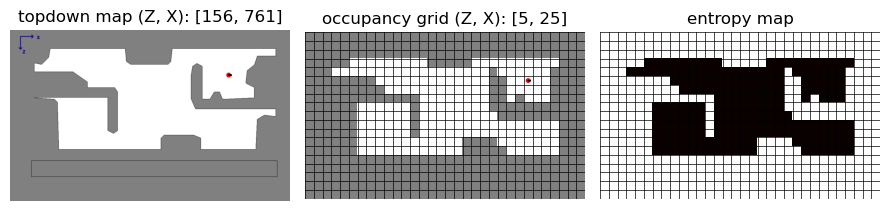

Action:  move_forward


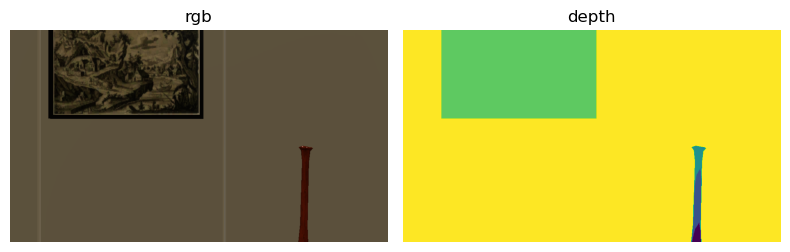

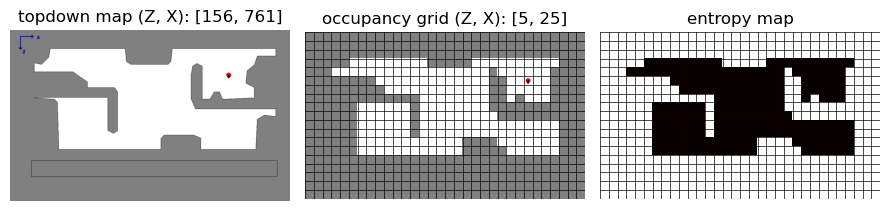

Action:  move_forward


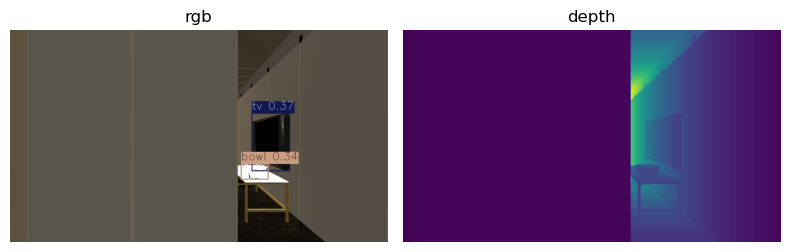

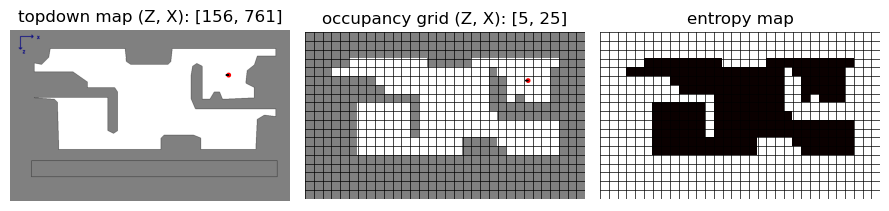

NEXT CLUSTER: [5, 18]
PATH: [[4, 25], [3, 25], [3, 24], [3, 23], [3, 22], [3, 21], [3, 20], [3, 19], [4, 19], [4, 18], [5, 18]]
Action:  move_right


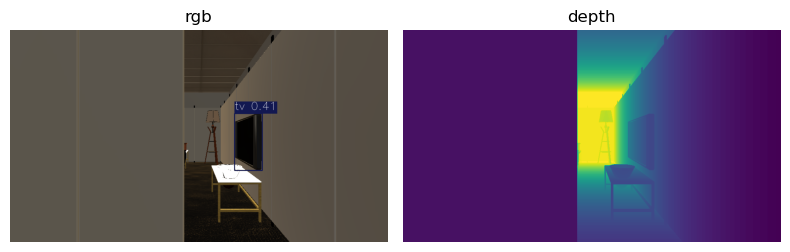

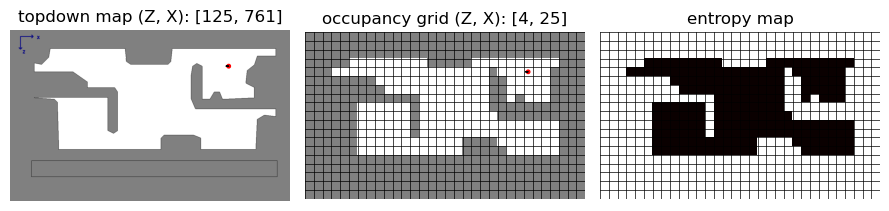

Action:  move_right


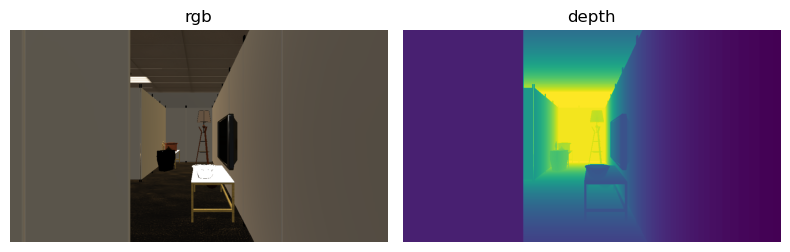

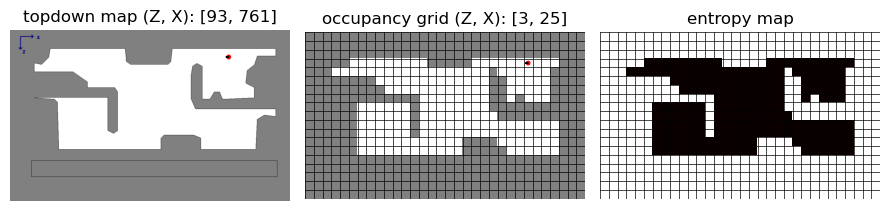

Action:  move_forward


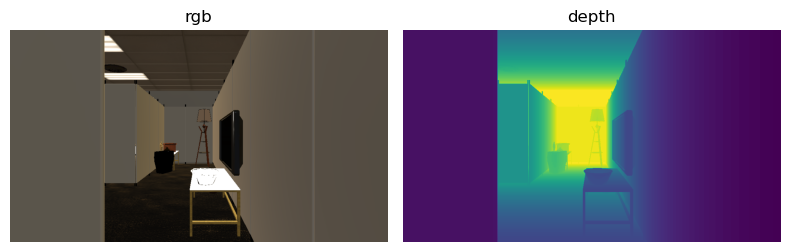

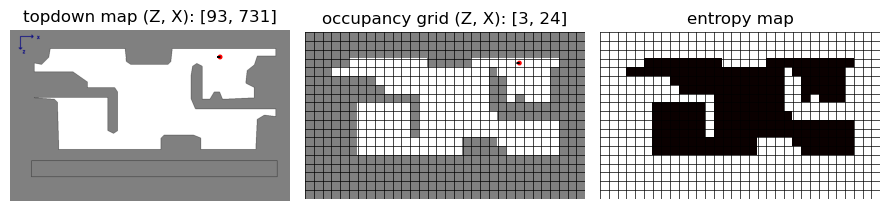

Action:  move_forward


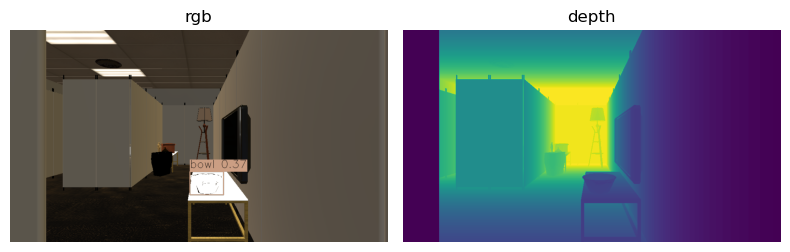

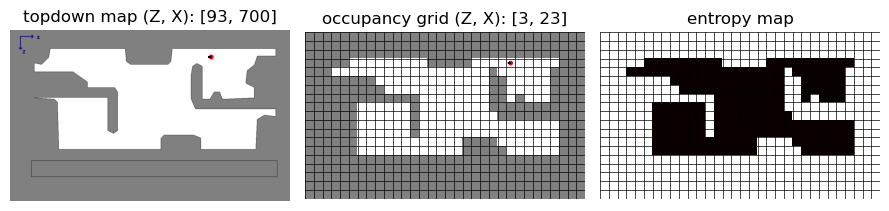

Action:  move_forward


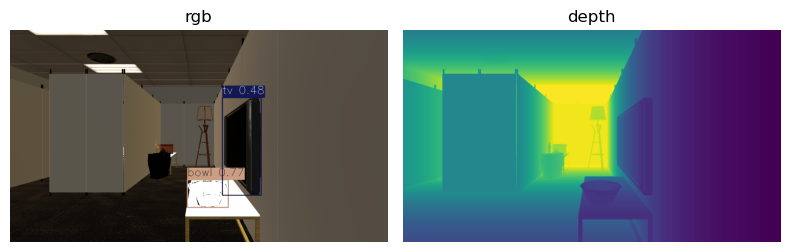

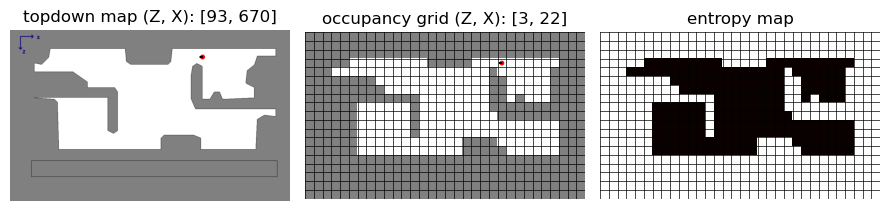

Action:  move_forward


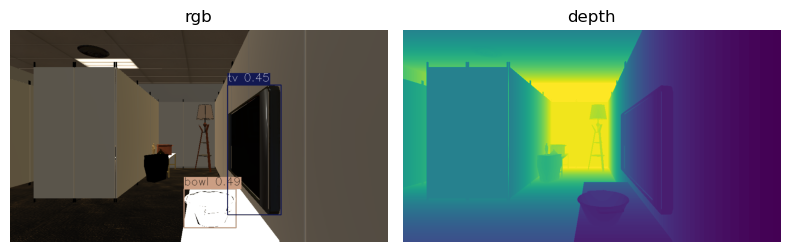

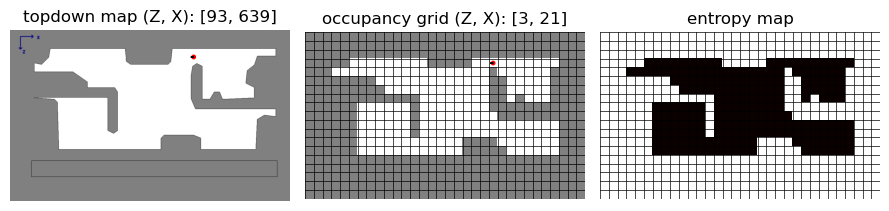

Action:  move_forward


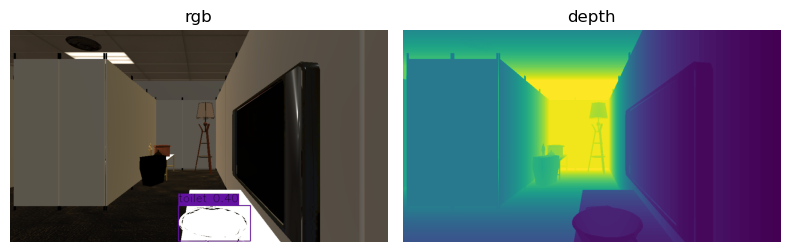

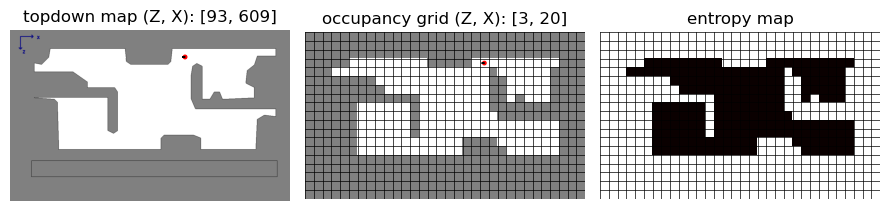

Action:  move_forward


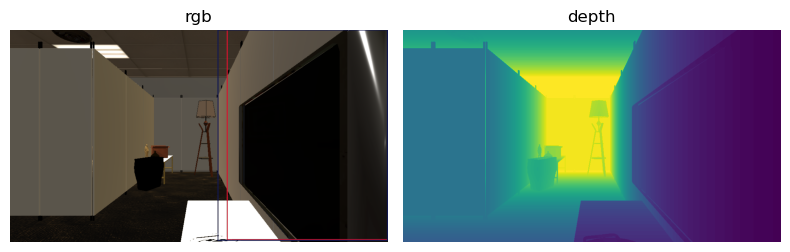

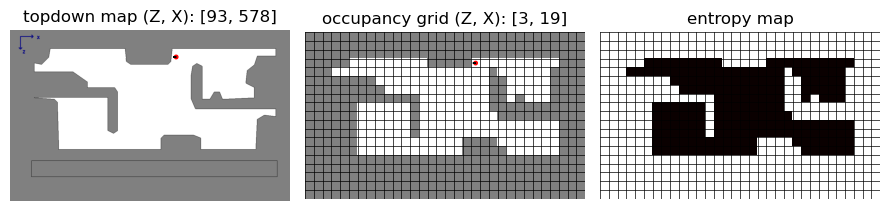

Class: handbag, Bin Index: 3, Scale: 0.11121961805555555
Dirichlet PDF: x=[ 0.00046527  2.0394e-07  2.9844e-06  2.1605e-07  3.7974e-06  2.5329e-07  7.5209e-07  2.4135e-06   0.0002447  4.1673e-06  0.00016239  3.7567e-06  2.5437e-05  5.3426e-07   0.0025067  0.00021896  1.2905e-05  4.4931e-07  3.3447e-06  1.4738e-07  8.5987e-08  1.1646e-05  2.6119e-08  1.2503e-06  7.2936e-07  0.00021884
  4.0263e-05  8.3139e-06  3.7269e-07  3.2468e-06  1.2393e-07  1.8862e-07  1.9997e-05  6.6244e-06  5.4008e-06  1.9745e-08  1.4944e-06  1.3365e-06  2.6232e-06      0.3893  0.00012002   0.0011557  2.7639e-05  0.00014914  0.00022108  1.1908e-05   0.0003971  0.00012474  3.6161e-06  6.8613e-06  0.00018968  4.5202e-06
  2.9098e-06  1.1367e-06  5.8137e-07  3.2643e-05  1.0066e-05  1.4013e-06   0.0020669  1.0448e-06  4.9068e-07  4.7851e-05  5.4285e-06   3.946e-06  6.3589e-07  0.00012455  6.5869e-08  2.1241e-05  7.5764e-07  4.6226e-07  8.6872e-07  6.9068e-07  4.4473e-06   1.043e-05  1.7952e-05    0.060502  1.3144e-05

ValueError: Input vector x must sum to 1.

In [7]:
# Main simulation loop
while (num_clusters <= MAX_NUM_CLUSTERS) and (num_actions < MAX_ITER) and (not OBJECT_FOUND):
    
    # Cluster free grid cells
    print("-------------------------------")
    print(f"Number of clusters: {num_clusters}")
    cluster_map = simtools.cluster_mapping(grid_occ_positions, num_clusters)
    grid_clusters = simtools.get_cluster_centers(cluster_map, num_clusters)
    simtools.display_topdown_maps_with_clusters(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw, cluster_map, num_clusters, grid_clusters)
    print("-------------------------------")

    # Go through each cluster center
    while (grid_clusters) and (num_actions < MAX_ITER) and (not OBJECT_FOUND):

        # Select closest cluster center to move to and the path to it
        grid_cluster, path = simtools.get_closest_cluster_path(grid_position, grid_clusters, grid_occ_positions)
        print(f"NEXT CLUSTER: {grid_cluster}")
        print(f"PATH: {path}")

        # 1 - Move along the path to the cluster center
        while (path) and (num_actions < MAX_ITER) and (not OBJECT_FOUND):
            
            # Compute optimal rotation to face the end of the path and action to achieve it
            facing_yaw = simtools.compute_facing_rotation(grid_position, path[-1])
            action = simtools.compute_rotation_action(agent_yaw, facing_yaw)

            # Perform a rotation action if needed
            if action is not None:
                grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1
                
                # Get observations
                observations = sim.get_sensor_observations(0)
                rgb = observations["color_sensor"]
                depth = observations["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
                simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)
                OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)

                # Kaplan-Update for belief map
                for i in range(num_detections):
                    box = xyxy[i].astype(int)
                    class_id = int(cls[i])
                    confidence = conf[i][0]
                    name = names[class_id]
                    prob_vector = prob_vectors[i]
                    scale = myutils.compute_bbox_scale(box, rgb)

                    # Get the bounding box of the detected object
                    x1, y1, x2, y2 = box
                    center_x = int((x1 + x2) / 2)
                    center_y = int((y1 + y2) / 2)
                    depth_value = depth[center_y, center_x]

                    # Compute the real world position of the detected object
                    object_position = simtools.compute_real_world_position(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, cam_intrcs)

                    # Convert to 2D coordinates
                    object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, occ_grid_resolution, sim.pathfinder)

                    # Perform the Kaplan-Update for the belief map
                    # TODO:

                    # Likelihood vector: use bbox scale and position to compute the likelihood of each class (it does not have to sum to 1)
                    likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)
                    print(f"Likelihood vector: {likelihood_vector}")

                    # Use the likelihood vector to update the belief map in that cell

                # Compute entropy map
                entropy_map = simtools.compute_entropy_map(belief_map, occ_grid_map)

                # Display the simulation state 
                print("Action: ", action)
                simtools.display_sim_observations(rgb, depth)
                simtools.display_topdown_and_entropy_maps(topdown_map, occ_grid_map, entropy_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

            # Check if object was found
            if OBJECT_FOUND: break

            # Compute the move action to move to next path cell and perform it
            action = simtools.compute_move_action_relative(grid_position, path[0], agent_yaw)
            grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
            idx = grid_occ_positions.index(grid_position)
            map_position = map_occ_positions[idx]
            wrld_position = real_wrld_positions[idx]
            agent_positions_tpl = (map_position, grid_position)
            agent_state.position = wrld_position
            agent.set_state(agent_state)

            # Update metrics
            travelled_distance += CELL_SIDE
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
            simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)
            OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)

            # Kaplan-Update for belief map
            for i in range(num_detections):
                box = xyxy[i].astype(int)
                class_id = int(cls[i])
                confidence = conf[i][0]
                name = names[class_id]

                # Get the bounding box of the detected object
                x1, y1, x2, y2 = box
                center_x = int((x1 + x2) / 2)
                center_y = int((y1 + y2) / 2)
                depth_value = depth[center_y, center_x]

                # Compute the real world position of the detected object
                object_position = simtools.compute_real_world_position(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, cam_intrcs)

                # Convert to 2D coordinates
                object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, occ_grid_resolution, sim.pathfinder)

                # Perform the Kaplan-Update for the belief map
                # TODO:

            # Compute entropy map
            entropy_map = simtools.compute_entropy_map(belief_map, occ_grid_map)

            # Display the simulation state 
            print("Action: ", action)
            simtools.display_sim_observations(rgb, depth)
            simtools.display_topdown_and_entropy_maps(topdown_map, occ_grid_map, entropy_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)
            
            # Remove the path cell from the path
            path.pop(0)

        # If the target object is found, break
        if OBJECT_FOUND: break

        # 2 - Take observations at the cluster center
        print(f"Taking observations at cluster center: {grid_cluster}")
        for i in range(3):

            # Perform the action
            grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
            agent_quart = myutils.yaw_to_quaternion(agent_yaw)
            agent_state.rotation = agent_quart
            agent.set_state(agent_state)

            # Update metrics
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
            simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)
            OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)
            
            # Kaplan-Update for belief map
            for i in range(num_detections):
                box = xyxy[i].astype(int)
                class_id = int(cls[i])
                confidence = conf[i][0]
                name = names[class_id]

                # Get the bounding box of the detected object
                x1, y1, x2, y2 = box
                center_x = int((x1 + x2) / 2)
                center_y = int((y1 + y2) / 2)
                depth_value = depth[center_y, center_x]

                # Compute the real world position of the detected object
                object_position = simtools.compute_real_world_position(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, cam_intrcs)

                # Convert to 2D coordinates
                object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, occ_grid_resolution, sim.pathfinder)

                # Perform the Kaplan-Update for the belief map
                # TODO:

            # Compute entropy map
            entropy_map = simtools.compute_entropy_map(belief_map, occ_grid_map)

            # Display the simulation state 
            print("Action: ", action)
            simtools.display_sim_observations(rgb, depth)
            simtools.display_topdown_and_entropy_maps(topdown_map, occ_grid_map, entropy_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

            # If the target object is found, break
            if OBJECT_FOUND: break 

        # Remove the grid cluster center from the list
        grid_clusters.remove(grid_cluster)

    # Double the number of clusters
    num_clusters *= 2

In [8]:
print(max(prob_vector))

0.3893046


In [ ]:
# Main simulation loop
for step in range(MAX_ITER):

    # TODO: This will be only for the first iteration*********************************************
    # Select closest cluster center to move to
    wrld_obs_point, distance = simtools.get_closest_cluster_center(agent.get_state().position, wrld_obs_points, sim.pathfinder)

    # Set new positions
    wrld_position = wrld_obs_point
    idx = real_wrld_positions.index(wrld_obs_point)
    grid_position = grid_occ_positions[idx]
    map_position = map_occ_positions[idx]
    agent_positions_tpl = (map_position, grid_position)

    # Move to the closest cluster center
    agent_state.position = wrld_position    
    agent.set_state(agent_state)

    # Increment the number of actions and travelled distance
    travelled_distance += distance
    num_actions += 1

    # 4 observations per observation point
    for i in range(4):

        # Get observations
        observations = sim.get_sensor_observations(0)
        rgb = observations["color_sensor"]
        depth = observations["depth_sensor"]

        # YOLO Prediction and merging with RGB image
        results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
        simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)

        # TODO: Process detections
        for i in range(num_detections):

            # Extract data
            bbox = xyxy[i].astype(int)
            class_id = int(cls[i])
            confidence = conf[i][0]
            prob_vec = prob_vectors[i]

            # Check if the detected object is within the valid set
            if names[class_id] not in indoor_objects: continue

            # Get the bounding box of the target object
            x1, y1, x2, y2 = bbox
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)
            depth_value = depth[center_y, center_x]
            bbox_width = x2 - x1
            bbox_height = y2 - y1
            scale = bbox_width*bbox_height / (sim_settings['width'] * sim_settings['height'])*100

            # Compute the real world position and grid position of the c object
            obj_wrld_coords = simtools.compute_real_world_position(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, cam_intrcs)
            obj_map_coords, obj_grid_coords = simtools.get_2d_coords(obj_wrld_coords, topdown_resolution, occ_grid_resolution, sim.pathfinder)

            # Fetch the right Dirichlet prior
            bin_idx = myutils.bin_index(scale, classes_bins[names[class_id]])
            dirichlet_prior = dirichlet_priors[names[class_id]][bin_idx]

            # Apply Kaplan fusion to the corresponding cell in the belief map
            prior = belief_map[obj_grid_coords[0]][obj_grid_coords[1]]
            updated = probtools.kaplan_updat
            e(prior, prob_vec, dirichlet_prior)
            belief_map[obj_grid_coords[0]][obj_grid_coords[1]] = updated

        # Perform the action
        grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)

        # Update positions and rotation
        idx = grid_occ_positions.index(grid_position)
        map_position = map_occ_positions[idx]
        wrld_position = real_wrld_positions[idx]
        agent_positions_tpl = (map_position, grid_position)
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)

        # Compute travelled distance and update number of actions
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, wrld_position)
        num_actions += 1

        # Set agent state
        agent_state.position = wrld_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

    # TODO: Choose next obs point ---> 7. Evaluate expected uncertainty gain for all reachable cells
    best_gain = -float('inf')
    best_pose = None

    # Go through all valid observation points
    for obs_point in grid_obs_points:
        # Copy current belief map
        simulated_belief_map = copy.deepcopy(belief_map)

        for cell in grid:
            dist = compute_distance(candidate_pose, cell.center)
            dist_idx = get_dirichlet_index(dist)

            simulated = probtools.kaplan_update(
                simulated_belief_map[cell],
                probtools.get_expected_score_vector(simulated_belief_map[cell]),  # e.g. normalize current belief
                dist_idx
            )
            simulated_belief_map[cell] = simulated

        # 8. Calculate info gain (e.g., KL-div vs. current belief)
        gain = probtools.compute_total_kl(simulated_belief_map, belief_map)

        if gain > best_gain:
            best_gain = gain
            best_pose = candidate_pose

    # 9. Move to next pose
    agent.move_to(best_pose)
    visited_poses.append(best_pose)



    # Check if the target object is found
    OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)

    # Display the observations and maps
    if num_actions % DISPLAY_STEP == 0:
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

    # If the target object is found or 3 rotations are done, break
    if OBJECT_FOUND or i == 3: break 

    # Perform the action
    grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)

    # Update positions and rotation
    idx = grid_occ_positions.index(grid_position)
    map_position = map_occ_positions[idx]
    wrld_position = real_wrld_positions[idx]
    agent_positions_tpl = (map_position, grid_position)
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Compute travelled distance and update number of actions
    travelled_distance += simtools.compute_travelled_distance(agent_state.position, wrld_position)
    num_actions += 1

    # Set agent state
    agent_state.position = wrld_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)







